# Блок 1. Задача 3: дерево решений-регрессор

Цель: предсказать числовой показатель прогрессирования диабета.

Используется датасет `Diabetes` из `scikit-learn` и модель `DecisionTreeRegressor`.


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.tree import DecisionTreeRegressor

sns.set_theme(style="whitegrid")


## Загрузка и анализ данных


In [7]:
diabetes = load_diabetes(as_frame=True)
df_diabetes = diabetes.frame.copy()

display(df_diabetes.head())
print("Размер датасета:", df_diabetes.shape)
print("Пропуски по столбцам:")
print(df_diabetes.isna().sum())


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


Размер датасета: (442, 11)
Пропуски по столбцам:
age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64


## Подготовка данных


In [8]:
X = df_diabetes.drop(columns=["target"])
y = df_diabetes["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)


## Обучение модели


In [9]:
param_grid = {
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
}

grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=5,
)
grid.fit(X_train, y_train)

tree_regressor = grid.best_estimator_
print("Лучшие параметры:", grid.best_params_)


Лучшие параметры: {'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 2}


## Метрики и график качества


MSE: 3094.497
MAE: 45.181
R2: 0.416


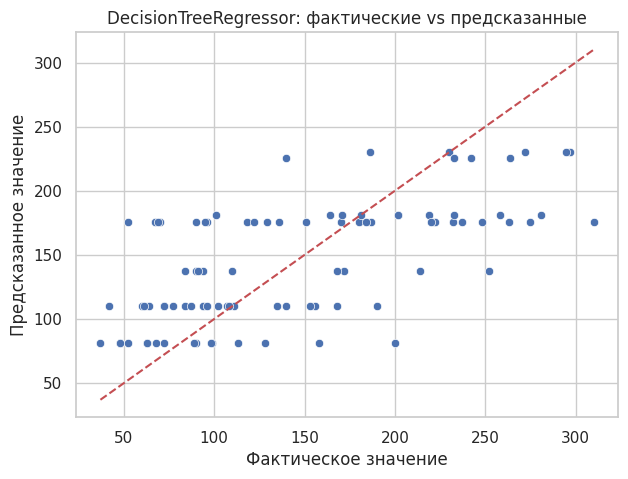

In [10]:
y_pred = tree_regressor.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", round(mse, 3))
print("MAE:", round(mae, 3))
print("R2:", round(r2, 3))

plt.figure(figsize=(7, 5))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Фактическое значение")
plt.ylabel("Предсказанное значение")
plt.title("DecisionTreeRegressor: фактические vs предсказанные")
plt.show()


## Вывод

Входные данные соответствуют задаче регрессии: используется датасет `Diabetes` размером `442 x 11`, в `X` входят `10` числовых медицинских признаков, а целевая переменная `y = target` является непрерывной количественной мерой прогрессирования болезни. Пропуски в признаках и целевой переменной отсутствуют.

По результатам `GridSearchCV` лучшими параметрами стали `max_depth = 3`, `min_samples_leaf = 5`, `min_samples_split = 2`. По текущему запуску на тестовой выборке получены `MSE = 3094.497`, `MAE = 45.181`, `R^2 = 0.416`.

Значение `R^2 = 0.416` означает, что дерево-регрессор объясняет около `41.6 %` вариации `target` на тестовой выборке. Ошибка `MAE = 45.181` показывает, что среднее абсолютное отклонение прогноза составляет примерно `45` единиц целевой переменной. Это средний уровень качества: модель улавливает часть зависимости, но заметная доля вариации остаётся необъяснённой.

Дерево решений-регрессор строит кусочно-постоянную зависимость и не требует предположения о линейной форме связи. При этом на текущем разбиении оно немного уступает линейной регрессии из первой задачи по `R^2`: `0.416` против `0.453`, и имеет более высокую среднюю абсолютную ошибку: `45.181` против `42.79`.
